##         Predict Diabetic Retinopathy Disease Project

**Project Setup & Initialization**:

**Business Objective**:

->This project aims to predict whether a patient will develop diabetic retinopathy using medical attributes such as age, blood pressure, and cholesterol levels.
Since the target variable (prognosis) has two values (0 or 1), this is a **Binary Classification Problem**.



#### STEP-1 :The dataset was loaded using pandas and stored in a dataframe for further analysis.

In [54]:
## Importing the required libraries.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
df = pd.read_csv("P653_pronostico_dataset.csv",sep=';')
df

,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,0,77.196340,85.288742,80.021878,79.957109,retinopathy
1,1,63.529850,99.379736,84.852361,110.382411,retinopathy
2,2,69.003986,111.349455,109.850616,100.828246,retinopathy
3,3,82.638210,95.056128,79.666851,87.066303,retinopathy
4,4,78.346286,109.154591,90.713220,92.511770,retinopathy
...,...,...,...,...,...,...
5995,5995,49.611850,94.857639,86.615671,107.643986,no_retinopathy
5996,5996,63.099686,100.039527,93.515186,104.971404,retinopathy
5997,5997,55.562243,98.421446,102.697875,120.875951,retinopathy
5998,5998,63.468956,106.809289,88.060631,106.052213,retinopathy


##### Getting the top 5 values by df.head()

In [56]:
df.head()

,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,0,77.196340,85.288742,80.021878,79.957109,retinopathy
1,1,63.529850,99.379736,84.852361,110.382411,retinopathy
2,2,69.003986,111.349455,109.850616,100.828246,retinopathy
3,3,82.638210,95.056128,79.666851,87.066303,retinopathy
4,4,78.346286,109.154591,90.713220,92.511770,retinopathy


##### Checking the shape of the data

In [57]:
df.shape

(6000, 6)

In [58]:
df.columns

Index(['ID', 'age', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'prognosis'], dtype='object')

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            6000 non-null   int64  
 1   age           6000 non-null   float64
 2   systolic_bp   6000 non-null   float64
 3   diastolic_bp  6000 non-null   float64
 4   cholesterol   6000 non-null   float64
 5   prognosis     6000 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 281.4+ KB


In [60]:
df.describe()

,ID,age,systolic_bp,diastolic_bp,cholesterol
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2999.500000,60.464121,100.694822,90.505547,100.628255
std,1732.195139,8.564392,10.669267,9.648200,10.433915
min,0.000000,35.164761,69.675429,62.807105,69.967453
25%,1499.750000,54.371941,93.267420,83.641788,93.202373
50%,2999.500000,59.831159,100.119926,89.912429,100.060637
75%,4499.250000,65.809652,107.439501,96.682405,107.250829
max,5999.000000,103.279497,151.699660,133.456382,148.233544


##### Checking the duplicates and null values 

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df= df.drop_duplicates()
df

,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,0,77.196340,85.288742,80.021878,79.957109,retinopathy
1,1,63.529850,99.379736,84.852361,110.382411,retinopathy
2,2,69.003986,111.349455,109.850616,100.828246,retinopathy
3,3,82.638210,95.056128,79.666851,87.066303,retinopathy
4,4,78.346286,109.154591,90.713220,92.511770,retinopathy
...,...,...,...,...,...,...
5995,5995,49.611850,94.857639,86.615671,107.643986,no_retinopathy
5996,5996,63.099686,100.039527,93.515186,104.971404,retinopathy
5997,5997,55.562243,98.421446,102.697875,120.875951,retinopathy
5998,5998,63.468956,106.809289,88.060631,106.052213,retinopathy


In [63]:
df.isnull().sum()

ID              0
age             0
systolic_bp     0
diastolic_bp    0
cholesterol     0
prognosis       0
dtype: int64

In [64]:
df.columns

Index(['ID', 'age', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'prognosis'], dtype='object')

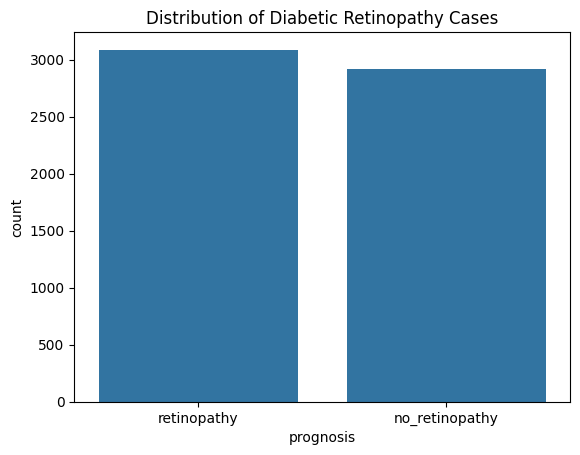

In [65]:
sns.countplot(x='prognosis', data=df)
plt.title("Distribution of Diabetic Retinopathy Cases")
plt.show()

##### EXPLORATORY DATA ANALYSIS IS STARTED FROM HERE WITH THE HISTOGRAMS

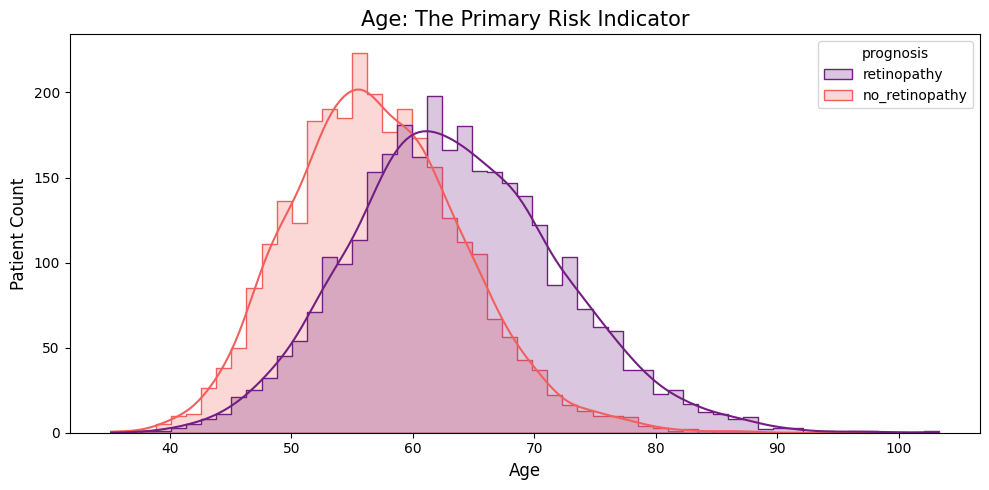

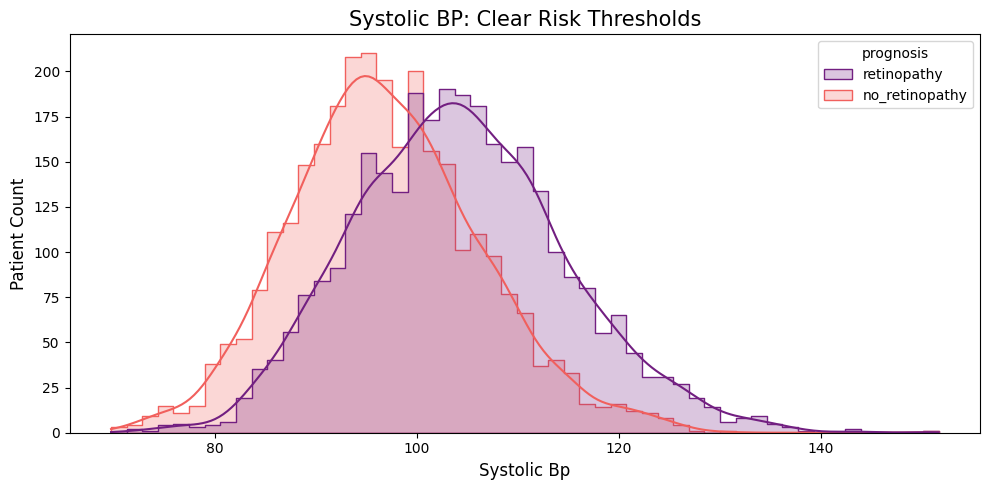

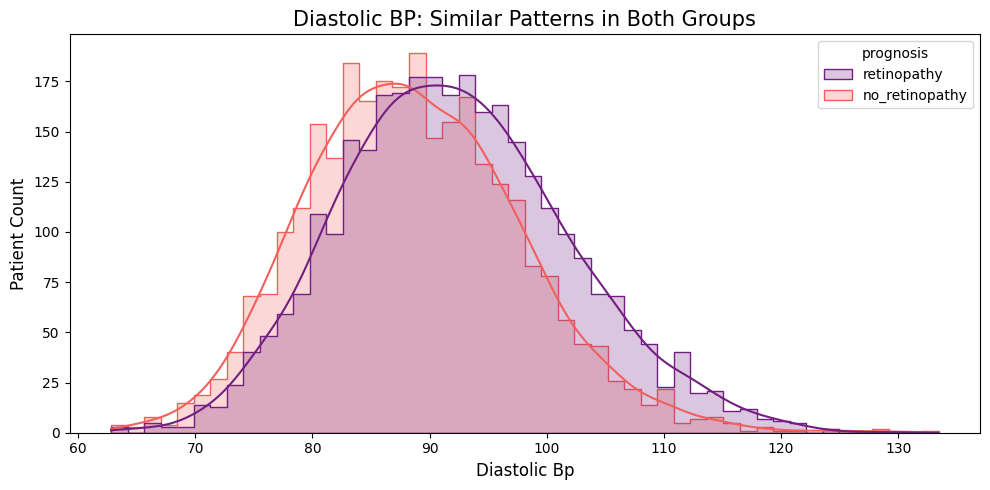

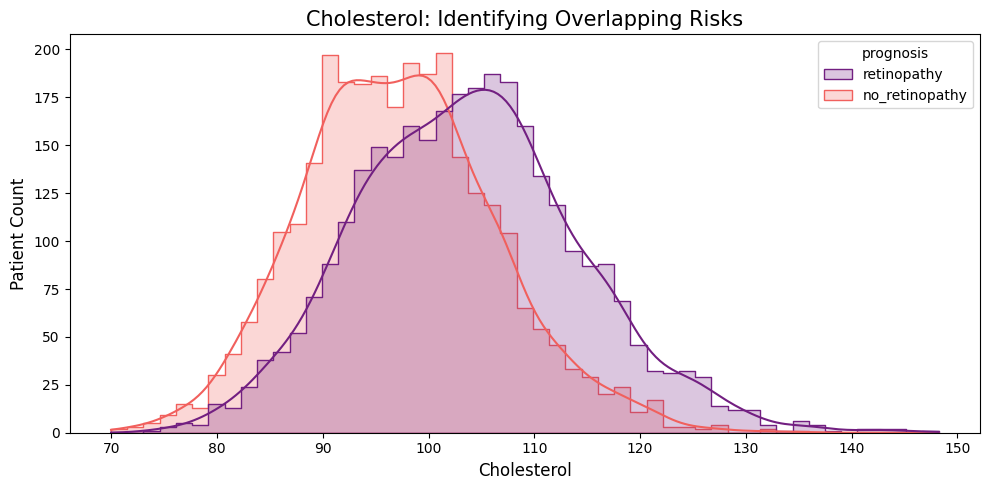

In [66]:
features = ['age', 'systolic_bp', 'diastolic_bp', 'cholesterol']
titles = [
    'Age: The Primary Risk Indicator',
    'Systolic BP: Clear Risk Thresholds',
    'Diastolic BP: Similar Patterns in Both Groups',
    'Cholesterol: Identifying Overlapping Risks'
]
for i, col in enumerate(features):
    plt.figure(figsize=(10, 5))
    
    # Using the 'magma' palette you liked from the Age graph
    sns.histplot(data=df, x=col, hue='prognosis', kde=True, element="step", palette='magma')
    
    plt.title(titles[i], fontsize=15)
    plt.xlabel(col.replace('_', ' ').title(), fontsize=12)
    plt.ylabel('Patient Count', fontsize=12)
    
    # This makes the layout clean so graphs don't overlap
    plt.tight_layout()
    plt.show()

In [67]:
columns = ['age', 'systolic_bp', 'diastolic_bp', 'cholesterol']
for col in columns:  
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR 
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, "outliers:", outliers.shape[0])

age outliers: 65
systolic_bp outliers: 55
diastolic_bp outliers: 55
cholesterol outliers: 54


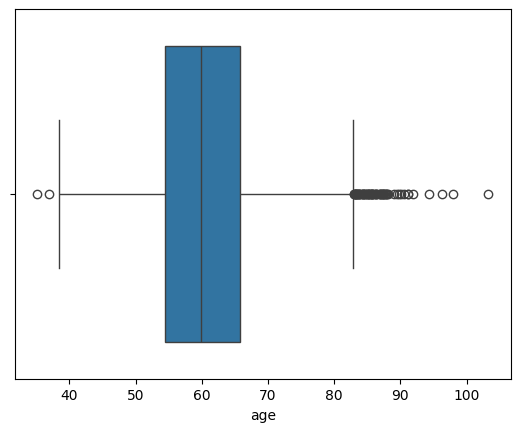

In [68]:
sns.boxplot(x=df['age'])
plt.show()

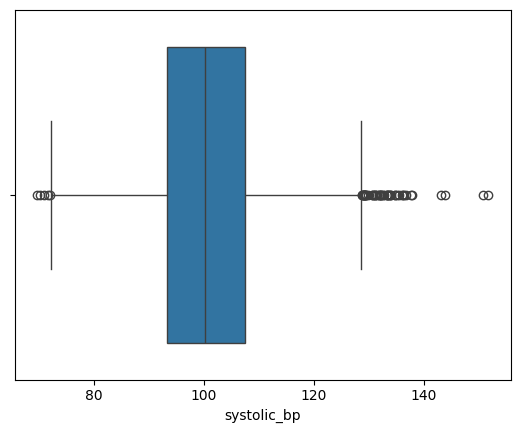

In [69]:
sns.boxplot(x=df["systolic_bp"])
plt.show()

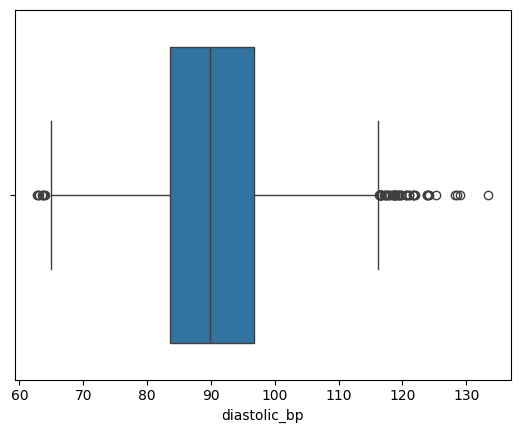

In [70]:
sns.boxplot(x=df["diastolic_bp"])
plt.show()

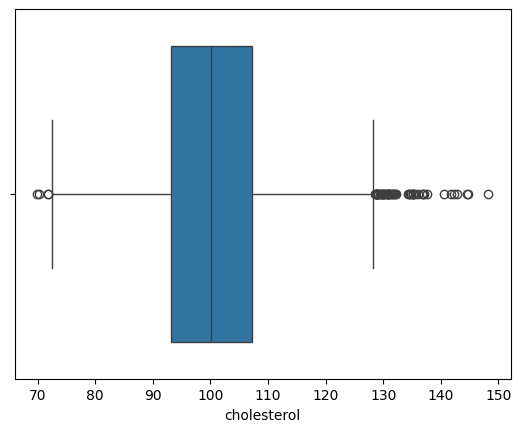

In [71]:
sns.boxplot(x=df["cholesterol"])
plt.show()

###### Identifying Clinical Risk Factors through Machine Learning

C:\Users\nalla\AppData\Local\Temp\ipykernel_10016\283179988.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='prognosis', y='age', data=df, palette='magma')


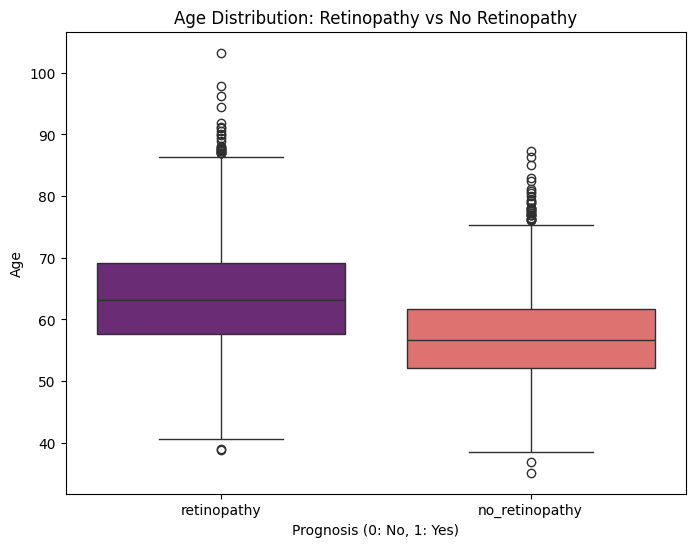

In [72]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='prognosis', y='age', data=df, palette='magma')
plt.title('Age Distribution: Retinopathy vs No Retinopathy')
plt.xlabel('Prognosis (0: No, 1: Yes)')
plt.ylabel('Age')
plt.show()

C:\Users\nalla\AppData\Local\Temp\ipykernel_10016\3943439000.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='prognosis', y='systolic_bp', data=df, palette='viridis')


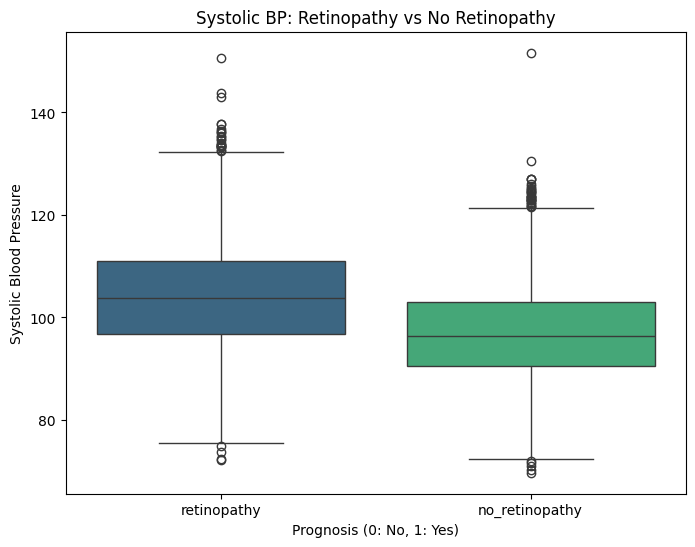

In [73]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='prognosis', y='systolic_bp', data=df, palette='viridis')
plt.title('Systolic BP: Retinopathy vs No Retinopathy')
plt.xlabel('Prognosis (0: No, 1: Yes)')
plt.ylabel('Systolic Blood Pressure')
plt.show()

C:\Users\nalla\AppData\Local\Temp\ipykernel_10016\2559211358.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='prognosis', y='diastolic_bp', data=df, palette='mako')


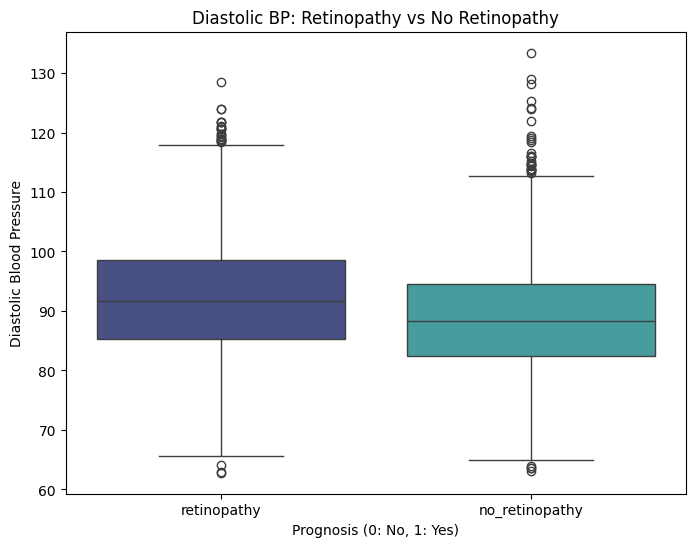

In [74]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='prognosis', y='diastolic_bp', data=df, palette='mako')
plt.title('Diastolic BP: Retinopathy vs No Retinopathy')
plt.xlabel('Prognosis (0: No, 1: Yes)')
plt.ylabel('Diastolic Blood Pressure')
plt.show()

C:\Users\nalla\AppData\Local\Temp\ipykernel_10016\363131938.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='prognosis', y='cholesterol', data=df, palette='rocket')


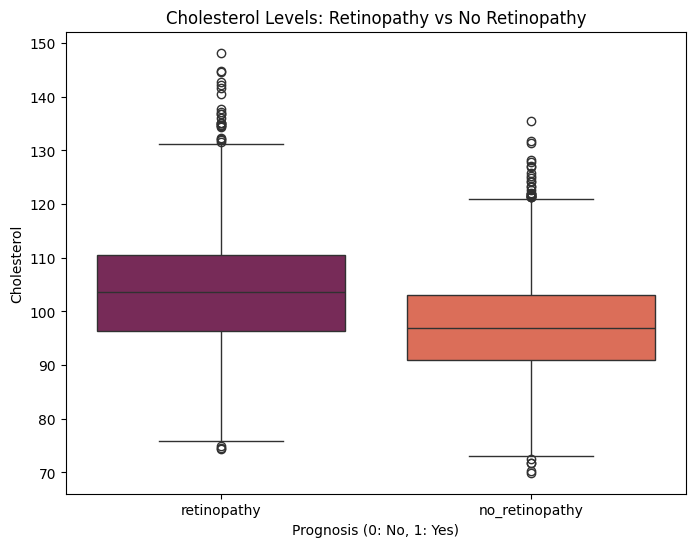

In [75]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='prognosis', y='cholesterol', data=df, palette='rocket')
plt.title('Cholesterol Levels: Retinopathy vs No Retinopathy')
plt.xlabel('Prognosis (0: No, 1: Yes)')
plt.ylabel('Cholesterol')
plt.show()

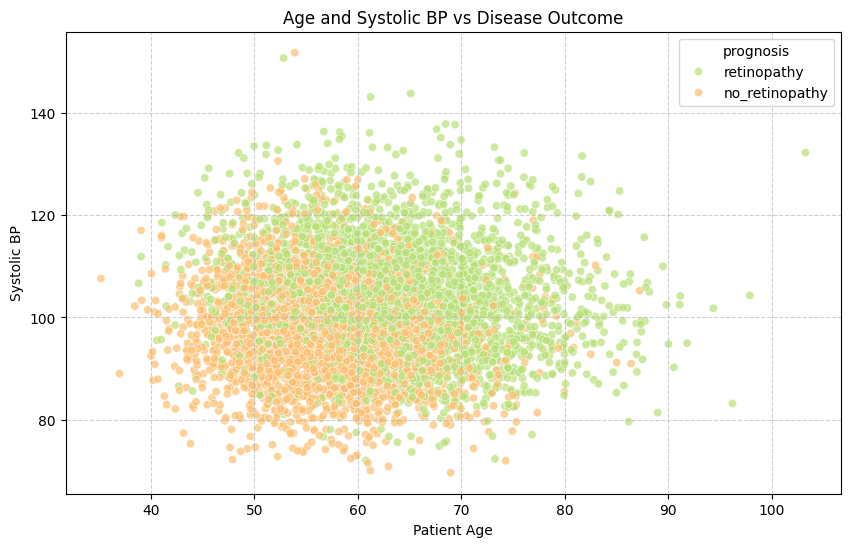

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='systolic_bp', hue='prognosis', palette='RdYlGn_r', alpha=0.7)

plt.title('Age and Systolic BP vs Disease Outcome')
plt.xlabel('Patient Age')
plt.ylabel('Systolic BP')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

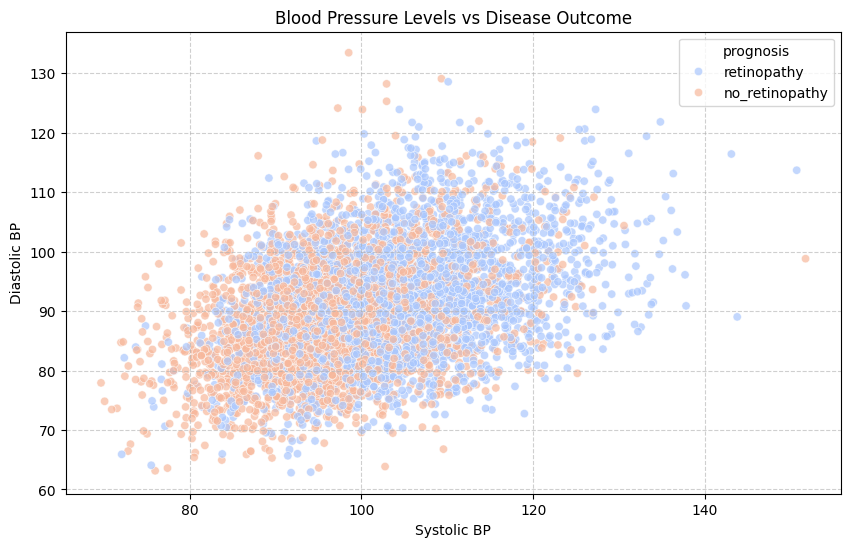

In [77]:
plt.figure(figsize=(10, 6))
# Using a different palette to make the difference pop
sns.scatterplot(data=df, x='systolic_bp', y='diastolic_bp', hue='prognosis', palette='coolwarm', alpha=0.7)

plt.title('Blood Pressure Levels vs Disease Outcome')
plt.xlabel('Systolic BP')
plt.ylabel('Diastolic BP')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

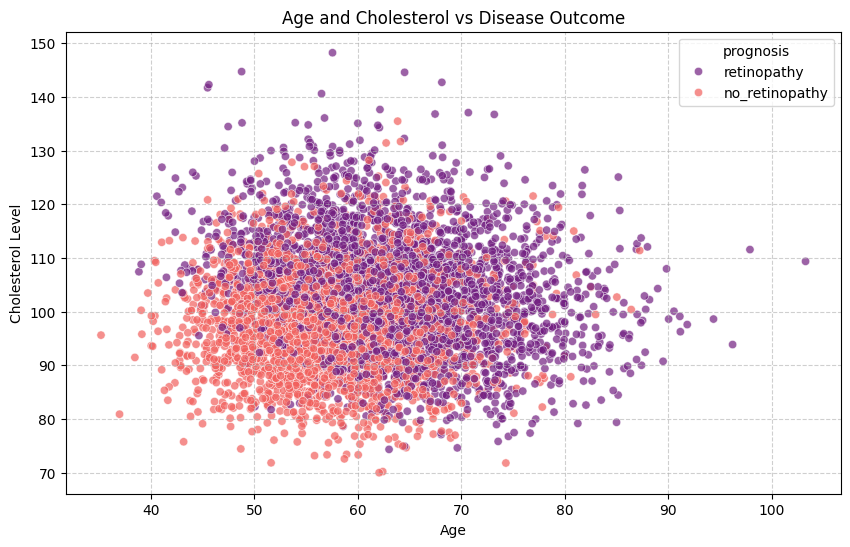

In [78]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='cholesterol', hue='prognosis', palette='magma', alpha=0.7)

plt.title('Age and Cholesterol vs Disease Outcome')
plt.xlabel('Age')
plt.ylabel('Cholesterol Level')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

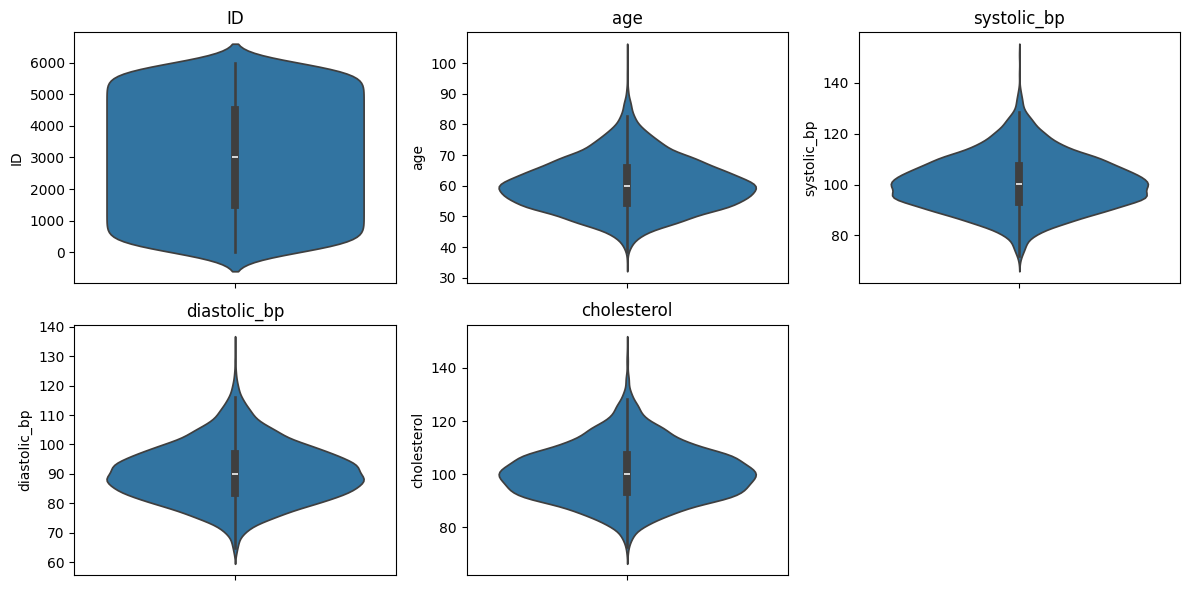

In [79]:
plt.figure(figsize=(12,6))
for i, col in enumerate(df.select_dtypes(include='number').columns):
    plt.subplot(2,3,i+1)
    sns.violinplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

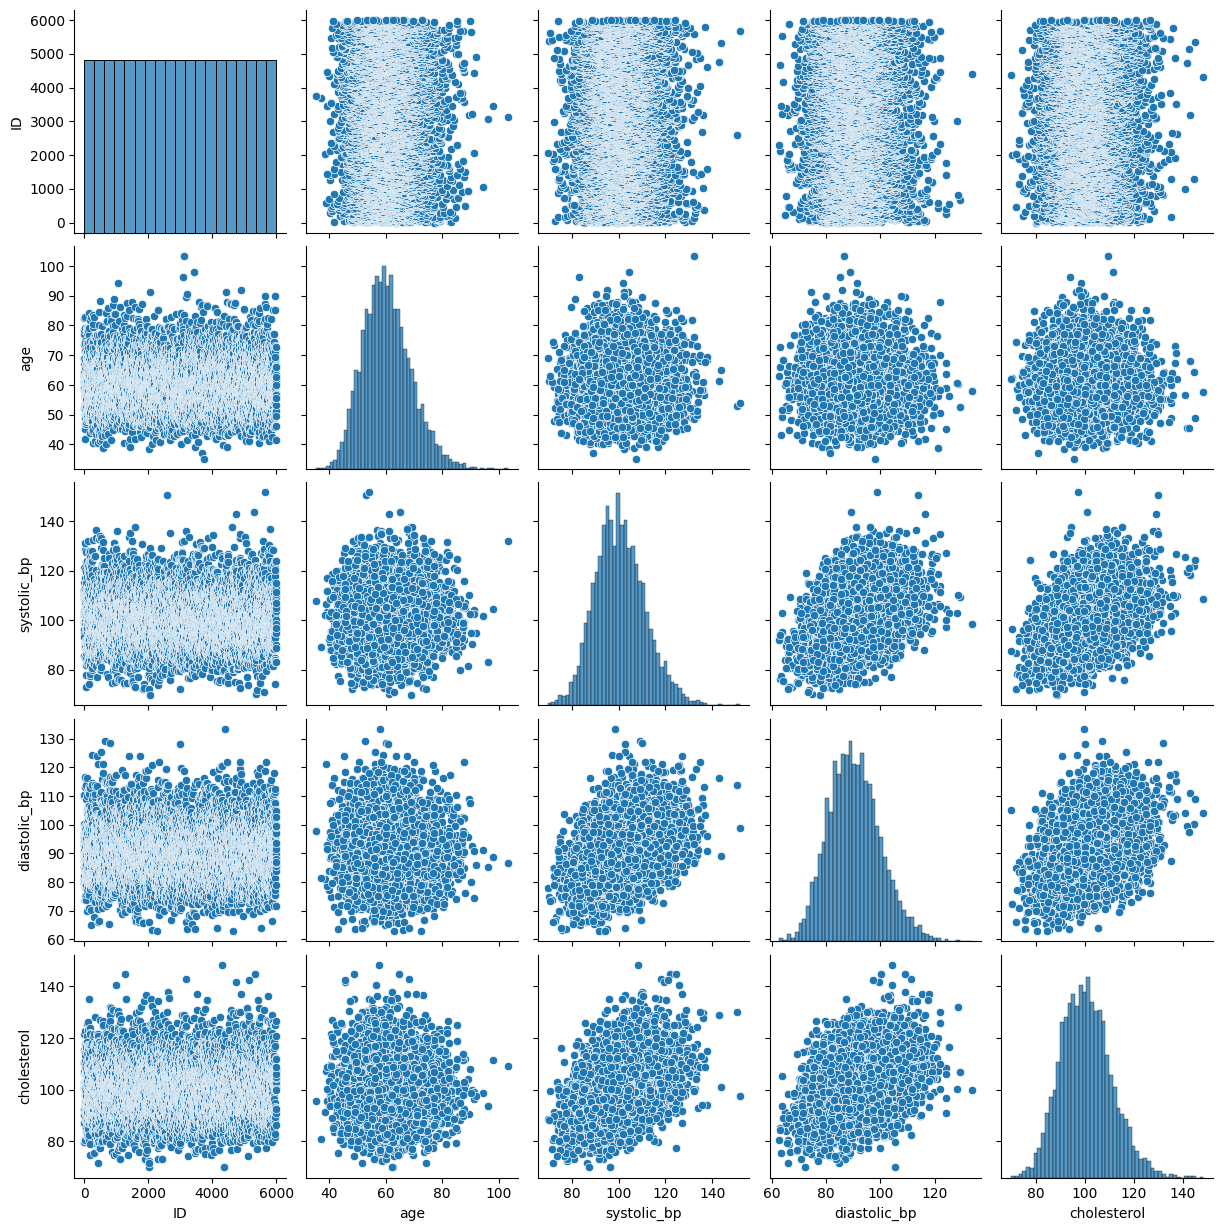

In [80]:
sns.pairplot(df)
plt.show()

In [81]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
df.corr(numeric_only=True)

,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
ID,1.000000,0.011357,-0.021189,-0.022656,0.010583,0.001756
age,0.011357,1.000000,0.010361,-0.005410,-0.006972,0.377440
systolic_bp,-0.021189,0.010361,1.000000,0.405406,0.406029,0.339842
diastolic_bp,-0.022656,-0.005410,0.405406,1.000000,0.398345,0.181541
cholesterol,0.010583,-0.006972,0.406029,0.398345,1.000000,0.315811
prognosis,0.001756,0.377440,0.339842,0.181541,0.315811,1.000000


In [82]:
df['prognosis'].unique()

array([1, 0])

In [83]:
prog_str = df['prognosis'].astype(str).str.strip().str.lower()
mapped = prog_str.map({
    'no_retinopathy': 0,
    'retinopathy': 1,
    '0': 0,
    '1': 1
})
numeric = pd.to_numeric(df['prognosis'], errors='coerce')
df['prognosis'] = mapped.fillna(numeric)
df = df.dropna(subset=['prognosis'])
df['prognosis'] = df['prognosis'].astype(int)

In [84]:
df.head()

,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,0,77.196340,85.288742,80.021878,79.957109,1
1,1,63.529850,99.379736,84.852361,110.382411,1
2,2,69.003986,111.349455,109.850616,100.828246,1
3,3,82.638210,95.056128,79.666851,87.066303,1
4,4,78.346286,109.154591,90.713220,92.511770,1


In [85]:
df.corr()

,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
ID,1.000000,0.011357,-0.021189,-0.022656,0.010583,0.001756
age,0.011357,1.000000,0.010361,-0.005410,-0.006972,0.377440
systolic_bp,-0.021189,0.010361,1.000000,0.405406,0.406029,0.339842
diastolic_bp,-0.022656,-0.005410,0.405406,1.000000,0.398345,0.181541
cholesterol,0.010583,-0.006972,0.406029,0.398345,1.000000,0.315811
prognosis,0.001756,0.377440,0.339842,0.181541,0.315811,1.000000


In [86]:
df = df.drop(columns=['ID'], errors='ignore')
df

,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,77.196340,85.288742,80.021878,79.957109,1
1,63.529850,99.379736,84.852361,110.382411,1
2,69.003986,111.349455,109.850616,100.828246,1
3,82.638210,95.056128,79.666851,87.066303,1
4,78.346286,109.154591,90.713220,92.511770,1
...,...,...,...,...,...
5995,49.611850,94.857639,86.615671,107.643986,0
5996,63.099686,100.039527,93.515186,104.971404,1
5997,55.562243,98.421446,102.697875,120.875951,1
5998,63.468956,106.809289,88.060631,106.052213,1


Correlation matrix:
                   age  systolic_bp  diastolic_bp  cholesterol  prognosis
age           1.000000     0.010361     -0.005410    -0.006972   0.377440
systolic_bp   0.010361     1.000000      0.405406     0.406029   0.339842
diastolic_bp -0.005410     0.405406      1.000000     0.398345   0.181541
cholesterol  -0.006972     0.406029      0.398345     1.000000   0.315811
prognosis     0.377440     0.339842      0.181541     0.315811   1.000000


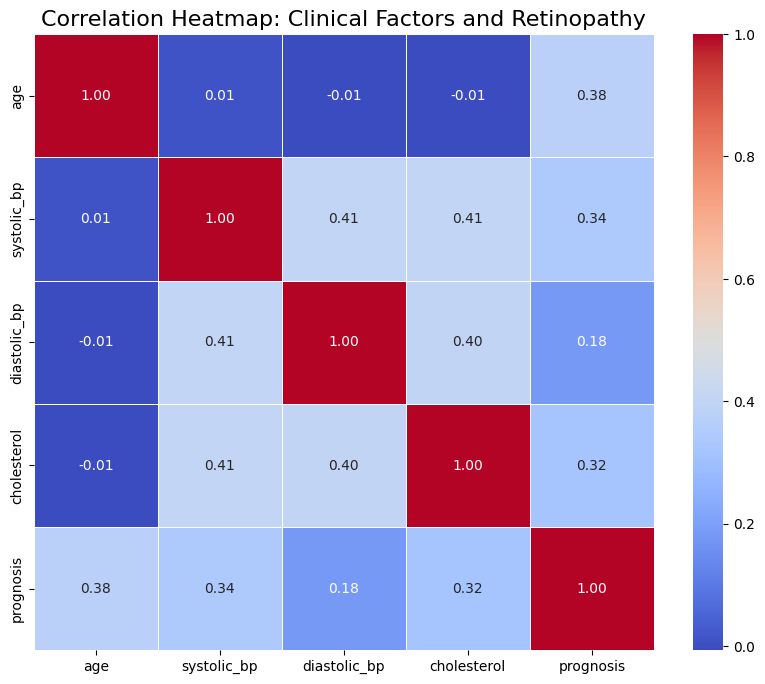

In [87]:
# 3. Calculate the correlation matrix
corr_matrix = df.corr()
# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Clinical Factors and Retinopathy', fontsize=16)
plt.savefig('correlation_heatmap.png')

print("Correlation matrix:")
print(corr_matrix)

In [88]:
X = df.drop('prognosis', axis=1)
y = df['prognosis']

In [89]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df.drop("prognosis", axis=1)
y = df["prognosis"]
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,age,systolic_bp,diastolic_bp,cholesterol
0,1.953859,-1.444088,-1.086684,-1.981315
1,0.357992,-0.123270,-0.585981,0.934929
2,0.997219,0.998712,2.005212,0.019169
3,2.589318,-0.528543,-1.123484,-1.299904
4,2.088141,0.792976,0.021526,-0.777959


In [90]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (4800, 4)
Testing Data Shape: (1200, 4)


## Next Step

**We will build machine learning models like** -

1️] Logistic Regression
2️]Decision Tree
3️]Random Forest
4️]Gradient Boosting / XGBoost

And we will compare accuracy, precision, recall, F1-score

In [91]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=4, random_state=42)

Training rows: 4800 | Testing rows: 1200
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}


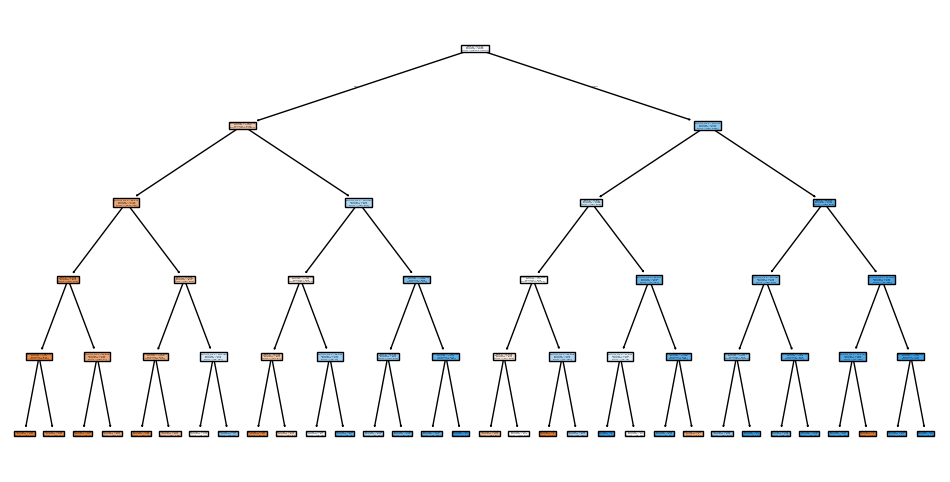

Model Accuracy: 0.7283333333333334


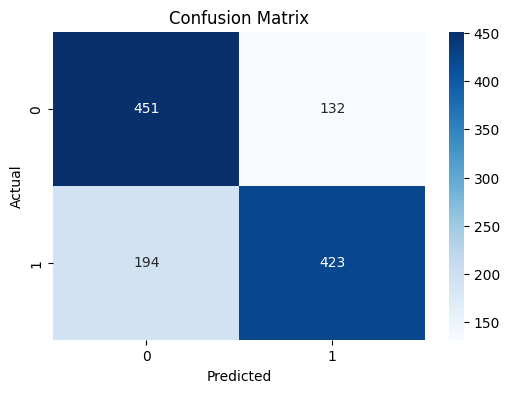

In [92]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Build a clean dataset directly from df so this cell runs independently
work_df = df.copy()
work_df = work_df.drop(columns=['ID'], errors='ignore')

prog_str = work_df['prognosis'].astype(str).str.strip().str.lower()
y_all = prog_str.map({'no_retinopathy': 0, 'retinopathy': 1, '0': 0, '1': 1})
y_all = y_all.fillna(pd.to_numeric(work_df['prognosis'], errors='coerce'))

valid_mask = y_all.notna()
X_all = work_df.loc[valid_mask].drop(columns=['prognosis'])
y_all = y_all.loc[valid_mask].astype(int)

for col in X_all.columns:
    X_all[col] = pd.to_numeric(X_all[col], errors='coerce')
X_all = X_all.fillna(X_all.median(numeric_only=True))

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)
print('Training rows:', len(y_train_clean), '| Testing rows:', len(y_test_clean))

# Decision Tree Model
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameter Grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3]
}

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train model on cleaned labels
grid_search.fit(X_train_clean, y_train_clean)
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Tree visualization
plt.figure(figsize=(12, 6))
plot_tree(best_model, feature_names=X.columns, filled=True)
plt.show()

# Predictions and metrics
y_pred = best_model.predict(X_test_clean)
accuracy = accuracy_score(y_test_clean, y_pred)
print("Model Accuracy:", accuracy)

cm = confusion_matrix(y_test_clean, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [93]:
from sklearn.metrics import classification_report
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.55      0.52       575
           1       0.53      0.47      0.50       625

    accuracy                           0.51      1200
   macro avg       0.51      0.51      0.51      1200
weighted avg       0.51      0.51      0.51      1200



In [94]:
from sklearn.tree import DecisionTreeClassifier  # or DecisionTreeRegressor
model = DecisionTreeClassifier()  # for classification
model.fit(X, y)
import pandas as pd
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)
print(feat_importances)

age             0.321064
cholesterol     0.262631
systolic_bp     0.259467
diastolic_bp    0.156837
dtype: float64


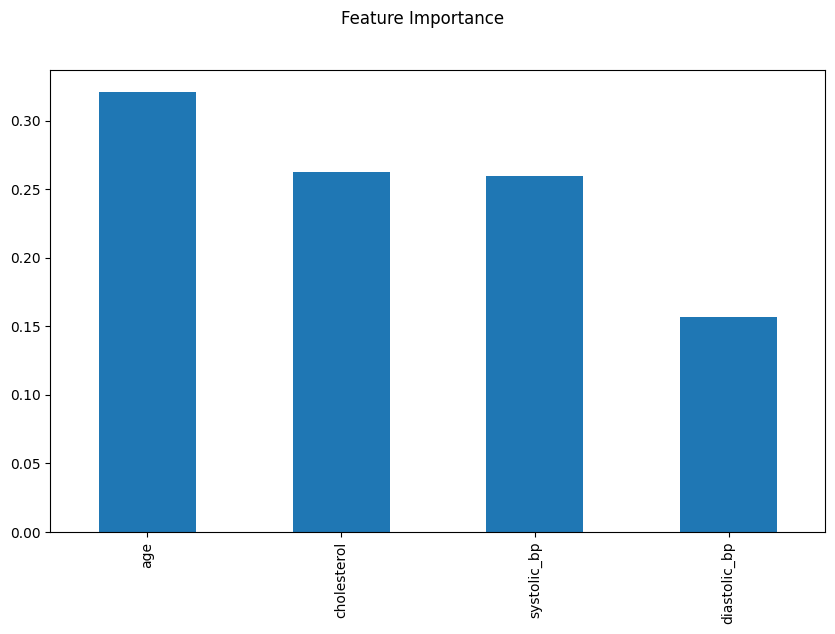

In [95]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
feat_importances.plot(kind='bar')
plt.suptitle("Feature Importance ")
plt.show()

## RANDOM FOREST MODEL

In [96]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf_model = RandomForestClassifier(
    n_estimators=500,      # more trees improves performance
    max_depth=10,          # controls overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy)


Random Forest Accuracy: 0.7516666666666667


In [97]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[421 154]
 [144 481]]


In [98]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.73      0.74       575
           1       0.76      0.77      0.76       625

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200



In [99]:
#Feature Importance
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

print("\nFeature Importance:")
print(feature_importance.sort_values(ascending=False))


Feature Importance:
age             0.378625
systolic_bp     0.268365
cholesterol     0.238532
diastolic_bp    0.114479
dtype: float64


##  LOGISTIC REGRESSION

In [100]:
# importing necessary libraries.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [101]:
# Define features and target
X = df.drop('prognosis', axis=1)
y = df['prognosis']

In [102]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [103]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [104]:
# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [105]:
# Prediction
y_pred = model.predict(X_test)

In [106]:
# Evaluation
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.7466666666666667


In [107]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.73      0.74      0.74       575
           1       0.76      0.75      0.75       625

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200



In [108]:
# Feature Importance for Logistic Regression
feature_importance = pd.Series(
    model.coef_[0],
    index=X.columns
)

print("\nFeature Importance:")
print(feature_importance.sort_values(ascending=False))


Feature Importance:
age             1.100750
systolic_bp     0.725211
cholesterol     0.614746
diastolic_bp   -0.016040
dtype: float64


## XGBOOST MODEL

In [109]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [110]:
import xgboost as xgb

In [111]:
from xgboost import XGBClassifier

In [112]:
# XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = loa

In [113]:
# Predictions using XGBoost

y_pred_xgb = xgb_model.predict(X_test)

In [114]:
# Accuracy

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7491666666666666


In [115]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.74      0.73      0.74       575
           1       0.76      0.77      0.76       625

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200



In [116]:
print("Logistic Regression Accuracy:", accuracy_score(y_test,y_pred))
print("XGBoost Accuracy:", accuracy_score(y_test,y_pred_xgb))


Logistic Regression Accuracy: 0.7466666666666667
XGBoost Accuracy: 0.7491666666666666


c:\Users\nalla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\nalla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


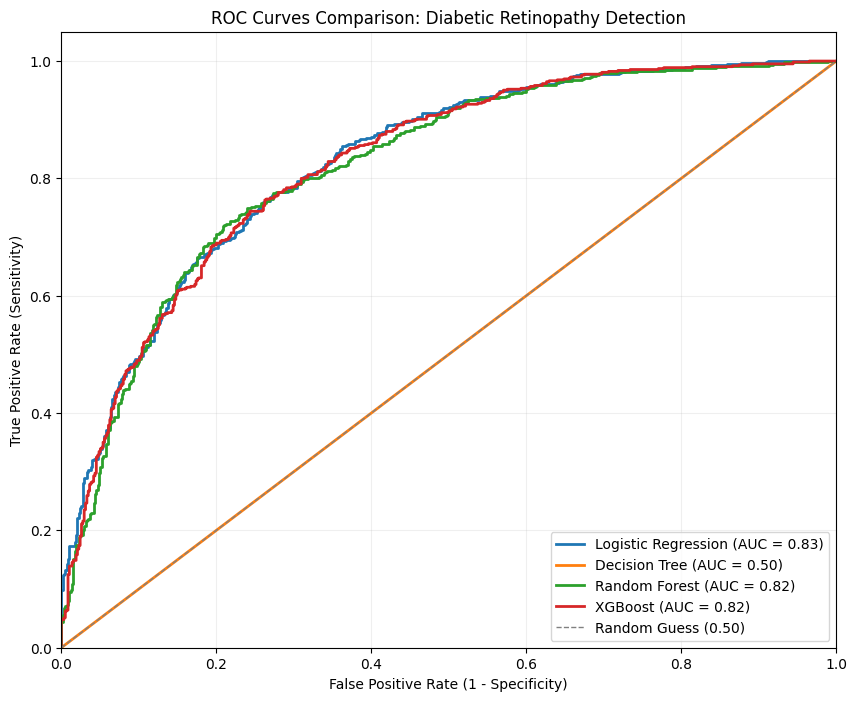

In [117]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Define your models in a dictionary for easy looping
# These variable names match the ones in your uploaded notebook
models_to_plot = {
    'Logistic Regression': model,
    'Decision Tree': best_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

plt.figure(figsize=(10, 8))

# 2. Iterate through each model to calculate and plot the ROC curve
for name, m in models_to_plot.items():
    # We need probabilities for the 'Positive' class (index 1)
    y_probs = m.predict_proba(X_test)[:, 1]
    
    # Calculate False Positive Rate and True Positive Rate
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # Plot the specific model's curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# 3. Add the 'Baseline' line (Random Guessing)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Guess (0.50)')

# 4. Final plot styling
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves Comparison: Diabetic Retinopathy Detection')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

C:\Users\nalla\AppData\Local\Temp\ipykernel_10016\3746540498.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=df_compare, palette='magma')


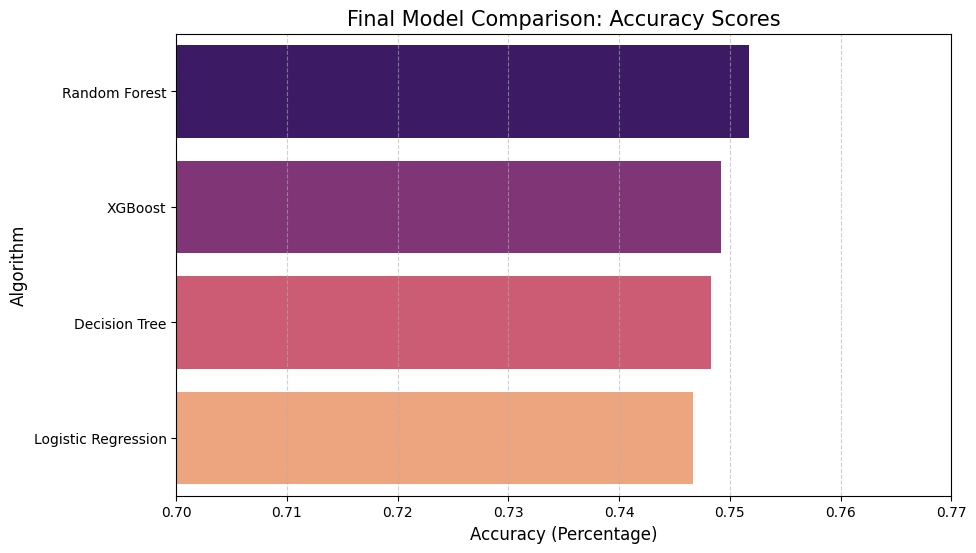

In [118]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data from your notebook outputs
data = {
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression', 'XGBoost'],
    'Accuracy': [0.7483, 0.7517, 0.7467, 0.7492]
}

df_compare = pd.DataFrame(data).sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
# Use the 'magma' palette you used in your EDA
sns.barplot(x='Accuracy', y='Model', data=df_compare, palette='magma')

plt.xlim(0.70, 0.77) # Zoom in to see the differences clearly
plt.title('Final Model Comparison: Accuracy Scores', fontsize=15)
plt.xlabel('Accuracy (Percentage)', fontsize=12)
plt.ylabel('Algorithm', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [122]:
import pickle

# assume your trained model is called 'model'
with open("retinopathy_model.pkl", "wb") as file:
    pickle.dump(xgb_model, file)

In [123]:
import pickle

with open("retinopathy_model.pkl", "rb") as file:
    model = pickle.load(file)